In [67]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

In [10]:
import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.7.1+cu118
0.22.1+cu118


In [11]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)
test_data = datasets.FashionMNIST(
    root="data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

In [12]:
len(train_data),len(test_data)

(60000, 10000)

In [13]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [14]:
image , label = train_data[0]

In [15]:
image.shape , label

(torch.Size([1, 28, 28]), 9)

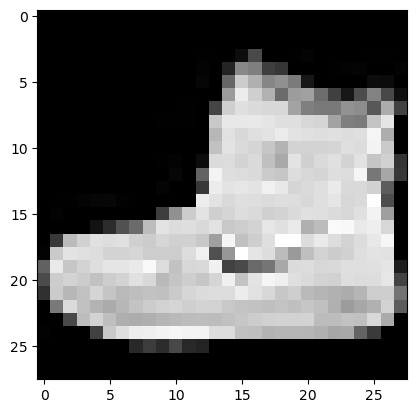

In [16]:
plt.imshow(image.squeeze(),cmap="gray")

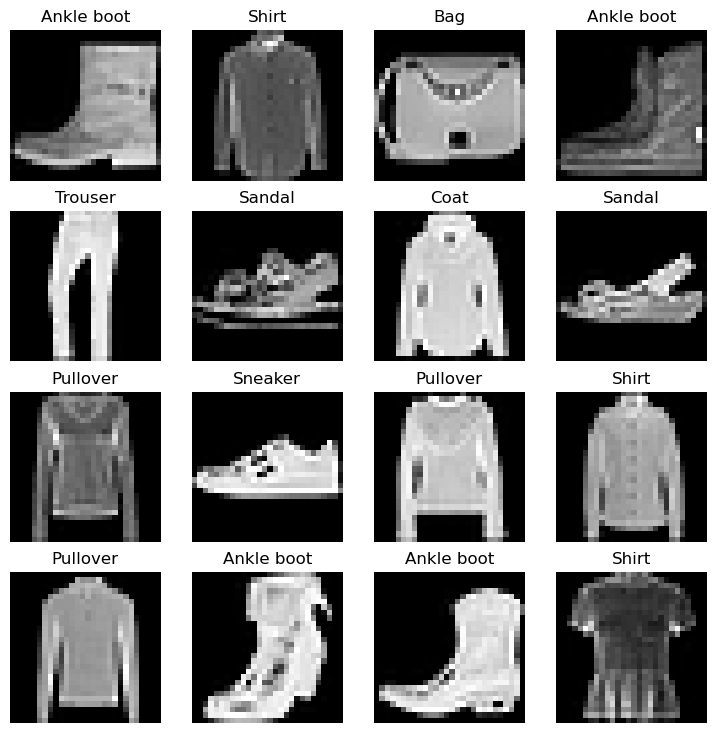

In [17]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows , cols = 4,4
for i in range(1,rows*cols+1):
    random_int = torch.randint(0,len(train_data),size=[1]).item()
    img , lebel =train_data[random_int]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_name[lebel])
    plt.axis(False)

In [18]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32 

data_loader = DataLoader(dataset=train_data,batch_size=BATCH_SIZE,shuffle=True)
data_loader_test = DataLoader(dataset = test_data , batch_size = BATCH_SIZE, shuffle = False)



In [19]:
data_loader , data_loader_test

(<torch.utils.data.dataloader.DataLoader at 0x250dbc6e510>,
 <torch.utils.data.dataloader.DataLoader at 0x250dc059a90>)

In [20]:
print(f"Data Loader {data_loader} test Loader {data_loader_test}")

Data Loader <torch.utils.data.dataloader.DataLoader object at 0x00000250DBC6E510> test Loader <torch.utils.data.dataloader.DataLoader object at 0x00000250DC059A90>


In [21]:
t_feature_b , t_labels_b = next(iter(data_loader))
t_feature_b.shape , t_labels_b.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

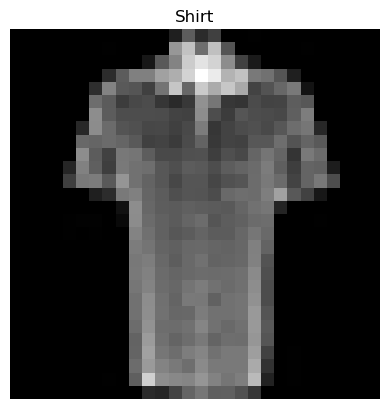

In [22]:
torch.manual_seed(42)
rand = torch.randint(0,len(t_feature_b),size=[1]).item()
img , label = t_feature_b[rand] , t_labels_b[rand]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_name[label])
plt.axis(False)

In [23]:
flatten_model = nn.Flatten()
x = t_feature_b[0]

In [24]:
out = flatten_model(x)
print(f"Shape before falttening : {x.shape}")
print(f"Shape after falttening {out.shape}")

Shape before falttening : torch.Size([1, 28, 28])
Shape after falttening torch.Size([1, 784])


In [25]:
from torch import nn
class FashionMBNISTV0(nn.Module):
    def __init__(self,input_shape:int , hidden_units:int,output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape , out_features = hidden_units),
            nn.Linear(in_features = hidden_units , out_features = output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

In [26]:
torch.manual_seed(42)
modelV0 = FashionMBNISTV0(784,10,len(class_name)).to("cpu")
modelV0

FashionMBNISTV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [27]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [28]:
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
    print("File already exist")
else :
    request = requests.get("raw.githubusercontent")
    with open("helper_function.py","wb") as f:
        f.write(request.content)

File already exist


In [29]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = modelV0.parameters(),lr = 0.1)

In [30]:
dummy_x = torch.rand([1,1,28,28])
modelV0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [31]:
modelV0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [32]:
from timeit import default_timer as timer
def print_train_time(start:float , end: float, device :torch.device = None):
    """Prints difference between Start and End time ."""
    total_time = end - start
    print(f"Train time on {device} : {total_time:.3f} seconds")
    return total_time

In [33]:
start_time = timer()

end_time = timer()
print_train_time(start=start_time , end=end_time,device = "cuda") 

Train time on cuda : 0.000 seconds


0.00014440002269111574

In [34]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n-----")
    train_loss=0
    for batch , (X,y) in enumerate(data_loader):
        modelV0.train()
        y_pred = modelV0(X)
        loss = loss_fn(y_pred , y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 ==0:
            print(f"Looked at {batch*len(X)}/{len(data_loader.dataset)}Burhan . .")
    train_loss /= len(data_loader)
    test_loss ,test_acc = 0,0
    modelV0.eval()
    with torch.inference_mode():
        for X_test,y_test in data_loader_test:
            test_pred = modelV0(X_test)
            test_loss += loss_fn(test_pred,y_test)
            test_acc += accuracy_fn(y_test ,test_pred.argmax(dim=1))
        test_loss /= len(data_loader_test)
        test_acc /= len(data_loader_test)
    print(f"\nTrain loss {train_loss:.4f} | Test loss:{test_loss:.4f} , Test acc :{test_acc:.4f}")
train_time_end = timer()
total_train_time_model = print_train_time(train_time_start,train_time_end,str(next(modelV0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
-----
Looked at 0/60000Burhan . .
Looked at 12800/60000Burhan . .
Looked at 25600/60000Burhan . .
Looked at 38400/60000Burhan . .
Looked at 51200/60000Burhan . .

Train loss 0.5904 | Test loss:0.5095 , Test acc :82.0387
Epoch 1
-----
Looked at 0/60000Burhan . .
Looked at 12800/60000Burhan . .
Looked at 25600/60000Burhan . .
Looked at 38400/60000Burhan . .
Looked at 51200/60000Burhan . .

Train loss 0.4763 | Test loss:0.4799 , Test acc :83.1969
Epoch 2
-----
Looked at 0/60000Burhan . .
Looked at 12800/60000Burhan . .
Looked at 25600/60000Burhan . .
Looked at 38400/60000Burhan . .
Looked at 51200/60000Burhan . .

Train loss 0.4550 | Test loss:0.4766 , Test acc :83.4265
Train time on cpu : 109.710 seconds


In [35]:
str(next(modelV0.parameters()).device)

'cpu'

In [36]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader : torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
              device:torch.device=device):
    """Returns a dictionary for model result"""
    loss , acc =0,0
    model.eval()
    with torch.inference_mode():
        for X , y in tqdm(data_loader):
            X , y = X.to(device),y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y,y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    print(f"Test Loss :{loss:.4f} Test Accuracy : {acc:.4f}")
    return {"model_name":model.__class__.__name__,
            "model_loss":loss.item(),
            "model":acc}

In [37]:
113/21

5.380952380952381

In [38]:
class FashionMNIST(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int , output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape , out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units , out_features = output_shape),
            nn.ReLU()
        )
    def forward(self,X):
        return self.layer_stack(X)

In [39]:
torch.manual_seed(42)
modelV2 = FashionMNIST(input_shape=784,hidden_units=10,output_shape = len(class_name)).to(device)

In [40]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = modelV2.parameters(),lr=0.1)

In [41]:
def Training_loop(model:torch.nn.Module,
                  loss_fn:torch.nn.Module,
                  optimizer:torch.optim.Optimizer,
                  data_loader:torch.utils.data.DataLoader,
                  accuracy_fn,
                  device :torch.device = device):
    """Perform Training Step."""
    train_loss ,acc= 0,0
    model.train()
    for batch , (X,y) in enumerate(data_loader):
        X , y = X.to(device), y.to(device)
        y_pred= model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss
        acc += accuracy_fn(y,y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss/=len(data_loader)
    acc/=len(data_loader)
    print(f"Train loss {train_loss:.5f} Train Accuracy {acc:.2f}...")


In [42]:
def Testing_loop(model:torch.nn.Module,
                  loss_fn:torch.nn.Module,
                  data_loader:torch.utils.data.DataLoader,
                  accuracy_fn,
                  device :torch.device = device):
    """Perform Testing Step."""
    test_loss ,acc= 0,0
    model.eval()
    with torch.inference_mode():
        for batch , (X,y) in enumerate(data_loader):
            X , y = X.to(device), y.to(device)
            y_pred= model(X)
            test_loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y,y_pred.argmax(dim=1))
        test_loss/=len(data_loader)
        acc/=len(data_loader)
    print(f"Test loss {test_loss:.5f} Test Accuracy {acc:.2f}...")

In [43]:
Training_loop(modelV2,loss_fn,optimizer,data_loader,accuracy_fn)

Train loss 1.05878 Train Accuracy 62.19...


In [44]:
Testing_loop(modelV2,loss_fn,data_loader_test,accuracy_fn)

Test loss 0.99506 Test Accuracy 64.13...


In [45]:
from tqdm.auto import tqdm
from timeit import default_timer as imer
torch.manual_seed(42)
torch.cuda.manual_seed(42)
start_time = timer()
epcohs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---------")
    Training_loop(modelV2,loss_fn,optimizer,data_loader,accuracy_fn)
    Testing_loop(modelV2,loss_fn,data_loader_test,accuracy_fn)
end_time=timer()
print_train_time(start=start_time,end=end_time,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
---------
Train loss 0.91147 Train Accuracy 66.28...
Test loss 0.91090 Test Accuracy 66.35...
Epoch 1
---------
Train loss 0.87764 Train Accuracy 67.33...
Test loss 0.88830 Test Accuracy 67.05...
Epoch 2
---------
Train loss 0.85843 Train Accuracy 67.83...
Test loss 0.89360 Test Accuracy 66.70...
Train time on cuda : 147.119 seconds


147.11890159998438

In [46]:
Testing_loop(modelV2,loss_fn,data_loader_test,accuracy_fn)

Test loss 0.89360 Test Accuracy 66.70...


In [47]:
result_modelV2 = eval_model(modelV2 , data_loader_test , loss_fn , accuracy_fn,device)
result_modelV2

  0%|          | 0/313 [00:00<?, ?it/s]

Test Loss :0.8936 Test Accuracy : 66.7033


{'model_name': 'FashionMNIST',
 'model_loss': 0.8936042785644531,
 'model': 66.70327476038338}

In [48]:
class ConvolutionalV0(nn.Module):
    """Model TinyVVG"""
    def __init__(self,input_shape:int,hidden:int,output_shape:int):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                     out_channels=hidden,
                     kernel_size=3,
                     stride = 1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                      out_channels=hidden,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block2= nn.Sequential(
            nn.Conv2d(in_channels=hidden,
                     out_channels = hidden,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden,
                     out_channels=hidden,
                     kernel_size =3,
                     stride =1,
                     padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden*7*7,out_features=output_shape)
        )
    
    def forward(self,X):
        X = self.conv_block1(X)
        X = self.conv_block2(X)
        return self.classifier(X)

In [49]:
torch.manual_seed(42)

modelV3 = ConvolutionalV0(1,10,len(class_name)).to(device)

In [50]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = modelV3.parameters(),lr = 0.1)


In [51]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer
st=timer()
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}")
    Training_loop(modelV3,loss_fn,optimizer,data_loader,accuracy_fn,device)
    Testing_loop(modelV3,loss_fn,data_loader_test,accuracy_fn,device)
en=timer()
total=print_train_time(st,en,device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
Train loss 0.59481 Train Accuracy 78.53...
Test loss 0.39330 Test Accuracy 85.70...
Epoch 1
Train loss 0.36393 Train Accuracy 86.83...
Test loss 0.35192 Test Accuracy 86.97...
Epoch 2
Train loss 0.32625 Train Accuracy 88.19...
Test loss 0.32966 Test Accuracy 88.14...
Train time on cuda : 189.962 seconds


In [52]:
model_3_result = eval_model(modelV3,data_loader_test,loss_fn,accuracy_fn,device)

  0%|          | 0/313 [00:00<?, ?it/s]

Test Loss :0.3297 Test Accuracy : 88.1390


In [53]:
model_3_result

{'model_name': 'ConvolutionalV0',
 'model_loss': 0.32966139912605286,
 'model': 88.13897763578275}

In [54]:
result_modelV2

{'model_name': 'FashionMNIST',
 'model_loss': 0.8936042785644531,
 'model': 66.70327476038338}

In [55]:
import pandas as pd
compare_result=pd.DataFrame([result_modelV2,model_3_result])
compare_result

,model_name,model_loss,model
0,FashionMNIST,0.893604,66.703275
1,ConvolutionalV0,0.329661,88.138978


In [56]:
def make_prediction(model:torch.nn.Module,
                   data:list,
                   device: torch.device=device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            print(f"Sample before {sample.shape}")
            sample = torch.unsqueeze(sample,dim=0).to(device)
            print(f"Sample after {sample.shape}")
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)

            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)


In [57]:
import random
#random.seed(42)
test_samples = []
test_labels = []
for sample , label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)

In [58]:
pred_prob = make_prediction(modelV3,test_samples)
pred_classes = pred_prob.argmax(dim=1)

Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])
Sample before torch.Size([1, 28, 28])
Sample after torch.Size([1, 1, 28, 28])


In [59]:
test_labels

[6, 6, 9, 1, 1, 1, 9, 5, 1]

In [60]:
#accuracy_fn(test_labels,pred_prob.argmax(dim=0))

In [61]:
test_samples[0].shape

torch.Size([1, 28, 28])

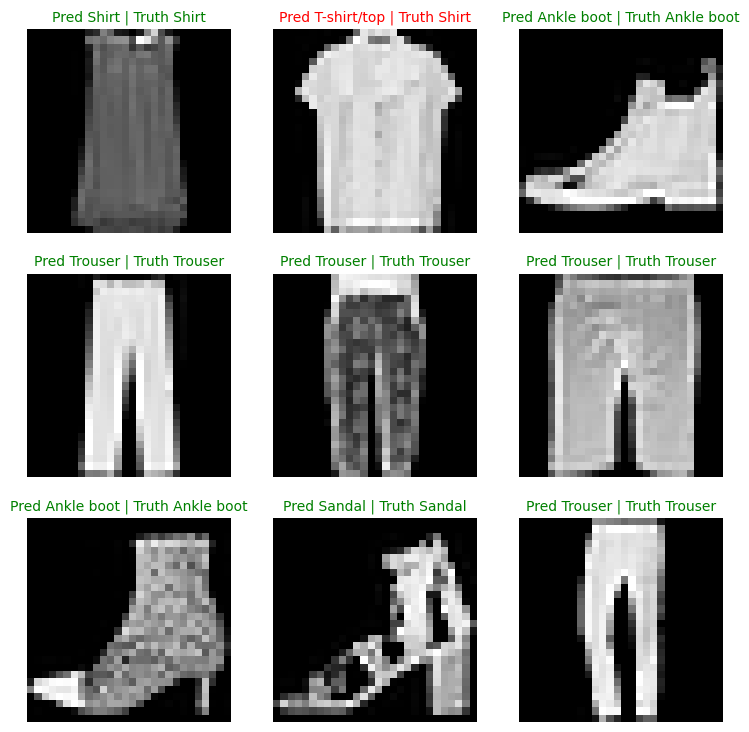

In [62]:
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.squeeze(),cmap="grey")
    pred_label=class_name[pred_classes[i]]
    true_label=class_name[test_labels[i]]
    title_test = f"Pred {pred_label} | Truth {true_label}"
    if pred_label==true_label:
        plt.title(title_test,fontsize=10,c="g")
    else :
        plt.title(title_test,fontsize=10,c="r")
    plt.axis(False)

In [63]:
from tqdm.auto import tqdm
y_preds = []
modelV3.eval()
with torch.inference_mode():
    for X , y in tqdm(data_loader_test,desc = "Making Predictions..."):
        X,y = X.to(device),y.to(device)
        y_logits = modelV3(X)
        y_pred = torch.softmax(y_logits.squeeze(),dim=0).argmax(dim=1)
        y_preds.append(y_pred.cpu())
#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]

Making Predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

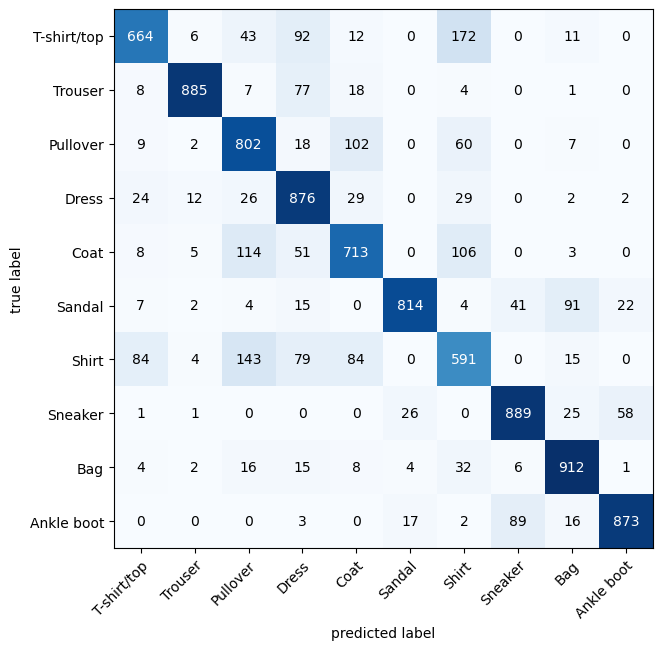

In [65]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes = len(class_name), task="multiclass")
confmat_tensor = confmat(preds  = y_pred_tensor,
                        target = test_data.targets)

fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_name,
    figsize=(10,7)
)

In [66]:
from pathlib import Path
model_p = Path("models")
model_p.mkdir(parents=True,exist_ok=True)
model_n = "CCN_FashionMNIST_m_03.pth"
model_s = model_p/model_n
torch.save(obj=modelV3.state_dict(),f=model_s)

In [68]:
import sys
print(sys.executable)

C:\Users\Burhan\anaconda3\python.exe
